# Detection Results Comparison : DINO against custom YOLO

In [11]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob
import matplotlib.patches as patches

# --- YOLO Imports ---
from ultralytics import YOLO

# --- Grounding DINO Imports ---
import groundingdino
from groundingdino.util.inference import load_model as load_dino_model, predict
import groundingdino.datasets.transforms as T



In [2]:

# ==========================================
# 1. CONFIGURATION & MODEL LOADING
# ==========================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- YOLO Setup ---
YOLO_WEIGHTS = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\ultralytics\runs\detect\Detection_For_IS\detection_Only_training_run4\weights\best.pt"  # Update with your custom YOLO path
print(f"Loading Custom YOLO on {DEVICE}...")
yolo_model = YOLO(YOLO_WEIGHTS)

# --- Grounding DINO Setup ---
dino_pkg_dir = os.path.dirname(groundingdino.__file__)
DINO_CONFIG = os.path.join(dino_pkg_dir, "config", "GroundingDINO_SwinT_OGC.py")
DINO_WEIGHTS = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\CLEAN_CODE\weights\detection\groundingdino_swint_ogc.pth" # Update if needed
print(f"Loading Grounding DINO on {DEVICE}...")
dino_model = load_dino_model(DINO_CONFIG, DINO_WEIGHTS).to(DEVICE)
DINO_PROMPT = "fish"


Loading Custom YOLO on cpu...
Loading Grounding DINO on cpu...


final text_encoder_type: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:

# ==========================================
# 2. INFERENCE HELPERS
# ==========================================
def get_yolo_predictions(image_bgr, conf_thresh=0.25):
    """Runs YOLO and returns a list of [x1, y1, x2, y2, conf, class_name]"""
    results = yolo_model.predict(image_bgr, conf=conf_thresh, verbose=False)[0]

    predictions = []
    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        conf = box.conf[0].cpu().item()
        cls_id = int(box.cls[0].cpu().item())
        cls_name = yolo_model.names[cls_id]
        predictions.append([int(x1), int(y1), int(x2), int(y2), conf, cls_name])

    return predictions

def get_dino_predictions(image_bgr, prompt, box_thresh=0.35, text_thresh=0.25):
    """Runs DINO and returns a list of [x1, y1, x2, y2, conf, phrase]"""
    # Transform for DINO
    transform = T.Compose([
        T.RandomResize([800], max_size=1333),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    image_pil = Image.fromarray(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    image_transformed, _ = transform(image_pil, None)

    # Predict
    boxes, logits, phrases = predict(
        model=dino_model,
        image=image_transformed,
        caption=prompt,
        box_threshold=box_thresh,
        text_threshold=text_thresh,
        device=DEVICE
    )

    if len(boxes) == 0:
        return []

    # Convert normalized [cx, cy, w, h] to absolute [x1, y1, x2, y2]
    h, w, _ = image_bgr.shape
    boxes_xyxy = boxes * torch.Tensor([w, h, w, h])
    boxes_xyxy[:, :2] -= boxes_xyxy[:, 2:] / 2  # top-left
    boxes_xyxy[:, 2:] += boxes_xyxy[:, :2]      # bottom-right

    predictions = []
    for i in range(len(boxes_xyxy)):
        x1, y1, x2, y2 = boxes_xyxy[i].cpu().numpy()
        conf = logits[i].cpu().item()
        phrase = phrases[i]
        predictions.append([int(x1), int(y1), int(x2), int(y2), conf, phrase])

    return predictions


In [4]:
# ==========================================
# 3. VISUALIZATION HELPER
# ==========================================
def draw_boxes(image_bgr, predictions, color=(0, 255, 0), thickness=2):
    """Draws bounding boxes and labels on a copy of the image."""
    img_draw = image_bgr.copy()
    for x1, y1, x2, y2, conf, label in predictions:
        # Draw Box
        cv2.rectangle(img_draw, (x1, y1), (x2, y2), color, thickness)

        # Draw Label Background
        text = f"{label} {conf:.2f}"
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.6
        text_size, _ = cv2.getTextSize(text, font, font_scale, 1)
        cv2.rectangle(img_draw, (x1, y1 - text_size[1] - 5), (x1 + text_size[0], y1), color, -1)

        # Draw Text
        cv2.putText(img_draw, text, (x1, y1 - 5), font, font_scale, (0, 0, 0), 2)

    return img_draw


In [5]:

def get_area(box):
    """Calculates the area of a bounding box [x1, y1, x2, y2]."""
    return max(0, box[2] - box[0]) * max(0, box[3] - box[1])

def calculate_overlap_metrics(boxA, boxB):
    """Calculates both Standard IoU and IoMin."""
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0.0, 0.0

    boxAArea = get_area(boxA)
    boxBArea = get_area(boxB)

    iou = interArea / float(boxAArea + boxBArea - interArea)
    io_min = interArea / float(min(boxAArea, boxBArea))

    return iou, io_min

def filter_overlapping_boxes_prefer_small(predictions, iou_threshold=0.45, iomin_threshold=0.80):
    """
    Filters overlapping bounding boxes, heavily favoring smaller, tighter boxes.
    """
    if len(predictions) <= 1:
        return predictions

    # ==========================================
    # PHASE 1: The "Anti-Swallow" Filter
    # If one box is swallowed by another, kill the LARGER box.
    # ==========================================
    skip_indices = set()

    for i in range(len(predictions)):
        if i in skip_indices:
            continue

        boxA = predictions[i][0:4]
        areaA = get_area(boxA)

        for j in range(i + 1, len(predictions)):
            if j in skip_indices:
                continue

            boxB = predictions[j][0:4]
            areaB = get_area(boxB)

            iou, io_min = calculate_overlap_metrics(boxA, boxB)

            # If the smaller box is almost entirely inside the larger box
            if io_min > iomin_threshold:
                # Mark the LARGER box for deletion
                if areaA > areaB:
                    skip_indices.add(i)
                    break # Box A is dead, stop comparing it and move to next i
                else:
                    skip_indices.add(j) # Box B is dead

    # Keep only the boxes that survived Phase 1
    phase_1_survivors = [predictions[i] for i in range(len(predictions)) if i not in skip_indices]

    # ==========================================
    # PHASE 2: Standard Confidence-Based NMS
    # Clean up any remaining standard overlaps by favoring higher confidence.
    # ==========================================
    # Sort survivors by confidence (index 4) descending
    sorted_preds = sorted(phase_1_survivors, key=lambda x: x[4], reverse=True)
    final_predictions = []

    for current_pred in sorted_preds:
        current_box = current_pred[0:4]
        keep = True

        for kept_pred in final_predictions:
            kept_box = kept_pred[0:4]
            iou, _ = calculate_overlap_metrics(current_box, kept_box)

            if iou > iou_threshold:
                keep = False
                break

        if keep:
            final_predictions.append(current_pred)

    return final_predictions


In [ ]:
# ==========================================
# 4. MANUAL STATIC COMPARISON
# ==========================================

def display_inline_comparison(image_path, yolo_conf=0.25, dino_box_thresh=0.30):
    """Processes a single image and prints a side-by-side Matplotlib visualization."""
    filename = os.path.basename(image_path)
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Error: Could not read image {filename}")
        return

    # Convert BGR to RGB for matplotlib presentation
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Inference & Filtering
    raw_dino_preds = get_dino_predictions(img_bgr, prompt=DINO_PROMPT, box_thresh=dino_box_thresh)
    raw_yolo_preds = get_yolo_predictions(img_bgr, conf_thresh=yolo_conf)
    dino_preds = filter_overlapping_boxes_prefer_small(raw_dino_preds)
    yolo_preds = filter_overlapping_boxes_prefer_small(raw_yolo_preds)

    # Setup Side-by-Side Plotting Configuration
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    fig.suptitle(f"Comparison: {filename}", fontsize=18, fontweight='bold', y=0.95)

    # --- Panel 1: Grounding DINO ---
    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Grounding DINO (Found: {len(dino_preds)})", fontsize=14, color='darkorange')
    axes[0].axis('off')
    for x1, y1, x2, y2, conf, label in dino_preds:
        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='darkorange', facecolor='none')
        axes[0].add_patch(rect)
        axes[0].text(x1, y1 - 8, f"{label} {conf:.2f}", color='white', fontsize=10,
                     weight='bold', bbox=dict(facecolor='darkorange', alpha=0.8, edgecolor='none', pad=2))

    # --- Panel 2: Custom YOLOv8 ---
    axes[1].imshow(img_rgb)
    axes[1].set_title(f"Custom YOLO (Found: {len(yolo_preds)})", fontsize=14, color='limegreen')
    axes[1].axis('off')
    for x1, y1, x2, y2, conf, label in yolo_preds:
        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='limegreen', facecolor='none')
        axes[1].add_patch(rect)
        axes[1].text(x1, y1 - 8, f"{label} {conf:.2f}", color='black', fontsize=10,
                     weight='bold', bbox=dict(facecolor='limegreen', alpha=0.8, edgecolor='none', pad=2))

    plt.tight_layout()
    plt.show()

Successfully tracked 101 images.


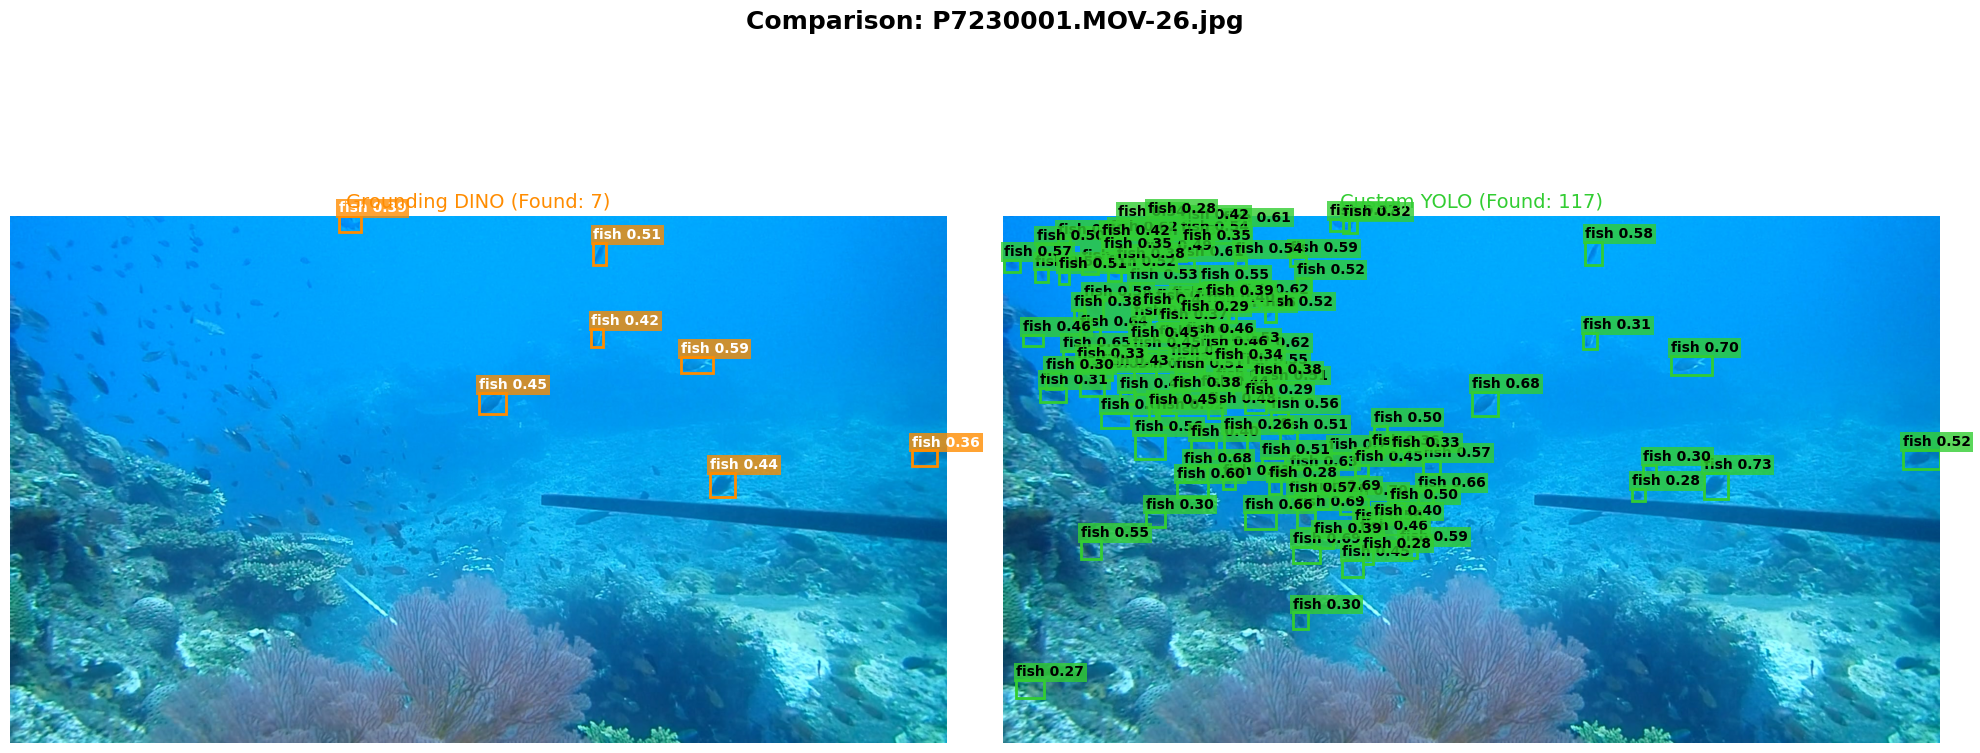

In [12]:
# 1. Collect and parse the targeted files
TEST_FOLDER = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\CLEAN_CODE\data\processed\UMT\untouched_images_for_assessment\selected_untouched_images"
valid_extensions = ('*.jpg', '*.jpeg', '*.png')
image_paths = []
for ext in valid_extensions:
    image_paths.extend(glob.glob(os.path.join(TEST_FOLDER, ext)))
image_paths.sort()

if not image_paths:
    print(f"No valid images found in: {TEST_FOLDER}")
else:
    print(f"Successfully tracked {len(image_paths)} images.")
    
    # --- INTERACTIVE CONTROL CELL ---
    # Adjust this index to step through your loaded dataset manually 
    image_index = 0 
    
    display_inline_comparison(
        image_paths[image_index], 
        yolo_conf=0.25, 
        dino_box_thresh=0.30
    )

In [ ]:

# ==========================================
# 5. INTERACTIVE COMPARISON
# ==========================================
def compare_inference(image_path):
    print(f"\nProcessing: {os.path.basename(image_path)}")
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("Error: Could not read image.")
        return

    # Run Inference
    yolo_preds = get_yolo_predictions(img_bgr, conf_thresh=0.25)
    dino_preds = get_dino_predictions(img_bgr, prompt=DINO_PROMPT, box_thresh=0.30, text_thresh=0.25)

    print(f"YOLO found {len(yolo_preds)} objects.")
    print(f"DINO found {len(dino_preds)} objects.")

    # Draw Results (YOLO in Green, DINO in Orange)
    img_yolo = draw_boxes(img_bgr, yolo_preds, color=(0, 255, 0))
    img_dino = draw_boxes(img_bgr, dino_preds, color=(0, 165, 255))

    # Convert BGR to RGB for matplotlib
    img_yolo_rgb = cv2.cvtColor(img_yolo, cv2.COLOR_BGR2RGB)
    img_dino_rgb = cv2.cvtColor(img_dino, cv2.COLOR_BGR2RGB)

    # Plot Side-by-Side
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    fig.suptitle(f"Detection Comparison: {os.path.basename(image_path)}", fontsize=20, fontweight='bold')

    axes[0].imshow(img_yolo_rgb)
    axes[0].set_title(f"Custom YOLOv8 (Found: {len(yolo_preds)})", fontsize=16)
    axes[0].axis('off')

    axes[1].imshow(img_dino_rgb)
    axes[1].set_title(f"Grounding DINO (Found: {len(dino_preds)})", fontsize=16)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()



def interactive_inference_viewer(image_dir, yolo_conf=0.25, dino_box_thresh=0.30):
    """
    Opens an interactive OpenCV window to compare YOLO and DINO side-by-side.

    Controls:
      [D] or [Right Arrow] : Next Image
      [A] or [Left Arrow]  : Previous Image
      [Q] or [ESC]         : Quit Viewer
    """
    # 1. Grab all images in the folder
    valid_extensions = ('*.jpg', '*.jpeg', '*.png')
    image_paths = []
    for ext in valid_extensions:
        image_paths.extend(glob.glob(os.path.join(image_dir, ext)))

    if not image_paths:
        print(f"No images found in {image_dir}")
        return

    # Sort paths alphabetically so they appear in a predictable order
    image_paths.sort()

    total_images = len(image_paths)
    current_idx = 0

    print(f"Loaded {total_images} images. Opening viewer...")
    print("CONTROLS: [D]=Next, [A]=Prev, [Q]=Quit")

    # Create a named window so we can resize it if it's too big for your screen
    window_name = "Model Comparison: DINO (Left) vs Custom YOLO (Right)"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

    while True:
        img_path = image_paths[current_idx]
        filename = os.path.basename(img_path)

        # Read Image
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            print(f"Failed to read {filename}. Skipping...")
            current_idx = (current_idx + 1) % total_images
            continue

       # --- 1. RUN INFERENCE ---
        raw_dino_preds = get_dino_predictions(img_bgr, prompt=DINO_PROMPT, box_thresh=dino_box_thresh)
        
        raw_yolo_preds = get_yolo_predictions(img_bgr, conf_thresh=yolo_conf)

        # --- 2. APPLY THE SMALL-BOX PREFERENCE FILTER ---
        dino_preds = filter_overlapping_boxes_prefer_small(raw_dino_preds)
        
        yolo_preds = filter_overlapping_boxes_prefer_small(raw_yolo_preds)

        # --- 3. DRAW BOXES ---
        img_dino = draw_boxes(img_bgr, dino_preds, color=(0, 165, 255)) # Orange
        
        img_yolo = draw_boxes(img_bgr, yolo_preds, color=(0, 255, 0))   # Green

        # Add titles to the top of each image
        font = cv2.FONT_HERSHEY_SIMPLEX
        # cv2.putText(img_dino, f"Grounding DINO (Found: {len(dino_preds)})", (20, 40), font, 1.2, (0, 165, 255), 3)
        cv2.putText(img_yolo, f"Custom YOLO (Found: {len(yolo_preds)})", (20, 40), font, 1.2, (0, 255, 0), 3)

        # --- 4. STITCH SIDE-BY-SIDE ---
        # Ensure they are the exact same height/width before stitching
        
        combined_img = np.hstack((img_dino, img_yolo))
        
        # combined_img = img_yolo # If you want to only show YOLO results, comment out the DINO part and use this line instead.
        
        
        # Add a footer with instructions and progress
        footer_h = 60
        footer = np.zeros((footer_h, combined_img.shape[1], 3), dtype=np.uint8)
        status_text = f"Image {current_idx + 1}/{total_images} : {filename} | Controls: [A]=Prev, [D]=Next, [Q]=Quit"
        cv2.putText(footer, status_text, (20, 40), font, 1.0, (255, 255, 255), 2)

        # Append footer to the bottom
        final_display = np.vstack((combined_img, footer))
        
        # Resize the final display if it's too large for the screen
        max_height = 800  # Max height for your monitor
        max_width = 1600  # Max width for your monitor
        
        h, w = final_display.shape[:2]
        if h > max_height or w > max_width:
            scaling_factor = min(max_height / h, max_width / w)
            new_w = int(w * scaling_factor)
            new_h = int(h * scaling_factor)
            final_display = cv2.resize(final_display, (new_w, new_h))

        # --- 5. SHOW AND WAIT FOR KEYPRESS ---
        cv2.imshow(window_name, final_display)

        # Wait indefinitely until a key is pressed
        key = cv2.waitKey(0) & 0xFF

        # --- 6. HANDLE KEYBOARD INPUT ---
        if key == ord('q') or key == 27:  # 'q' or ESC key
            print("Exiting viewer.")
            break

        elif key == ord('d') or key == 83: # 'd' or Right Arrow
            # Move forward, loop back to 0 if at the end
            current_idx = (current_idx + 1) % total_images

        elif key == ord('a') or key == 81: # 'a' or Left Arrow
            # Move backward, loop to the end if at 0
            current_idx = (current_idx - 1) % total_images

    # Clean up the OpenCV window when done
    cv2.destroyAllWindows()




In [ ]:
# ==========================================
# 6. RUN THE VIEWER
# ==========================================
# Make sure to point this to the folder containing your test images!
TEST_FOLDER = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\CLEAN_CODE\data\processed\UMT\untouched_images_for_assessment\selected_untouched_images"
YOLO_CONF_THRESHOLD = 0.25
DINO_BOX_THRESHOLD = 0.30

interactive_inference_viewer(TEST_FOLDER, yolo_conf=YOLO_CONF_THRESHOLD, dino_box_thresh=DINO_BOX_THRESHOLD)

`use_return_dict` is deprecated! Use `return_dict` instead!


Loaded 101 images. Opening viewer...
CONTROLS: [D]=Next, [A]=Prev, [Q]=Quit


Exiting viewer.
